In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import copy
import json
import os
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
)
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from scipy.stats import spearmanr


ROOT_DIR = "/content/drive/MyDrive/CompNeuroscience-P1"
FEATURES_DIR = f"{ROOT_DIR}/lamem_features2"
SAVE_DIR = f"{ROOT_DIR}/memorability_models"
os.makedirs(SAVE_DIR, exist_ok=True)


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda



# Inputs

* ViT (768-d): semantic image embedding, trained with language supervision.
* DINO (1024-d): self-supervised visual embedding. Captures texture, shape, composition.
* Emotions (originally one-hot-encoded) (5-d): One-hot-encoding of dominant emotion. 5 categories from the LaMem Dataset: amusement, excitement, awe, contentment, and sad
* Emotion scores (5-d): continuous softmax over 5 CLIP-vs-prompt similarities. How strongly the image aligns with each emotion category.
* Valence/Arousal (2-d) — BLIP-2 answers a scale question in natural language, parsed to a scalar. Rough sentiment/energy estimate.
* SBERT (384-d) — sentence embedding of BLIP-2 caption + emotion description concatenated. Captures free-form semantic + emotional content as text.


In [2]:
df = pd.read_parquet(f"{FEATURES_DIR}/lamem_features_full.parquet")
clip_mat = np.load(f"{FEATURES_DIR}/clip_embeddings.npy")    # (N, 768)
dino_mat = np.load(f"{FEATURES_DIR}/dino_embeddings.npy")    # (N, 1024)
sbert_mat    = np.load(f"{FEATURES_DIR}/sbert_embeddings.npy")   # (N, 384)

EMOTIONS = ["amusement", "excitement", "awe", "contentment", "sadness"]
memscore = df["memscore"].values.astype(np.float32)

# softmax
emotion_scores = df[[f"emotion_{e}" for e in EMOTIONS]].values.astype(np.float32)  # (N, 5)

valence_arousal = df[["valence", "arousal"]].values.astype(np.float32)             # (N, 2)

print(f"df: {df.shape}")
print(f"clip_mat: {clip_mat.shape}")
print(f"dino_mat: {dino_mat.shape}")
print(f"sbert_mat: {sbert_mat.shape}")
print(f"emotion_scores: {emotion_scores.shape}")
print(f"valence_arousal: {valence_arousal.shape}")
print(f"memscore range: [{memscore.min():.3f}, {memscore.max():.3f}]")

df: (16815, 19)
clip_mat: (16815, 768)
dino_mat: (16815, 1024)
sbert_mat: (16815, 384)
emotion_scores: (16815, 5)
valence_arousal: (16815, 2)
memscore range: [0.293, 0.988]


In [3]:
all_idx    = np.arange(len(df))
strat_bins = pd.qcut(df["memscore"], q=5, labels=False, duplicates="drop") # stratified

train_idx, temp_idx = train_test_split(
    all_idx, test_size=0.3, random_state=42, stratify=strat_bins
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42,
    stratify=strat_bins.iloc[temp_idx].values
)

print(f"Train : {len(train_idx):>6}  ({len(train_idx)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_idx):>6}  ({len(val_idx)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_idx):>6}  ({len(test_idx)/len(df)*100:.1f}%)")

Train :  11770  (70.0%)
Val   :   2522  (15.0%)
Test  :   2523  (15.0%)


In [4]:
# def fit_scaler(mat, idx):
#     """Compute mean and std on train split only."""
#     mu  = mat[idx].mean(axis=0, keepdims=True)
#     std = mat[idx].std(axis=0,  keepdims=True) + 1e-8
#     return mu, std

# def apply_scaler(mat, mu, std):
#     return ((mat - mu) / std).astype(np.float32)

# # # Fit on train, apply to all
# # clip_mu,  clip_std  = fit_scaler(clip_mat,      train_idx)
# # dino_mu,  dino_std  = fit_scaler(dino_mat,      train_idx)
# # sbert_mu, sbert_std = fit_scaler(sbert_mat,     train_idx)
# # emo_mu,   emo_std   = fit_scaler(emotion_scores, train_idx)
# # va_mu,    va_std    = fit_scaler(valence_arousal, train_idx)

# # clip_norm  = apply_scaler(clip_mat,       clip_mu,  clip_std)
# # dino_norm  = apply_scaler(dino_mat,       dino_mu,  dino_std)
# # sbert_norm = apply_scaler(sbert_mat,      sbert_mu, sbert_std)
# # emo_norm   = apply_scaler(emotion_scores, emo_mu,   emo_std)
# # va_norm    = apply_scaler(valence_arousal, va_mu,   va_std)

# print("All blocks normalised.")

In [5]:
clip_norm  = clip_mat
dino_norm  = dino_mat
sbert_norm = sbert_mat
emo_norm   = emotion_scores
va_norm    = valence_arousal

## 4 · Experiment registry

Each experiment is defined by a name and a list of feature blocks to concatenate. Adding a new experiment requires only a new entry here — training code is shared.

In [6]:
EXPERIMENTS = {
    "A_vit_only": {
        "blocks" : [clip_norm],
        "desc"   : "ViT only (baseline)",
    },
    "B_dino_only": {
        "blocks" : [dino_norm],
        "desc"   : "DINO only",
    },
    "C_vit_emo": {
        "blocks" : [clip_norm, emo_norm],
        "desc"   : "ViT + emotion scores",
    },
    "D_vit_emo_va": {
        "blocks" : [clip_norm, emo_norm, va_norm],
        "desc"   : "ViT + emotion scores + valence/arousal",
    },
    "E_vit_sbert": {
        "blocks" : [clip_norm, sbert_norm],
        "desc"   : "ViT + SBERT",
    },
    "F_vit_full": {
        "blocks" : [clip_norm, emo_norm, va_norm, sbert_norm],
        "desc"   : "ViT + emotion scores + valence/arousal + SBERT (full)",
    },
    "G_vit_dino": {
        "blocks" : [clip_norm, dino_norm],
        "desc"   : "ViT + DINO fusion",
    },
    "H_vit_dino_full": {
        "blocks" : [clip_norm, dino_norm, emo_norm, va_norm, sbert_norm],
        "desc"   : "ViT + DINO + emotion scores + valence/arousal + SBERT (kitchen sink)",
    },
}

for name, cfg in EXPERIMENTS.items():
    cfg["X"]   = np.concatenate(cfg["blocks"], axis=1)
    cfg["dim"]  = cfg["X"].shape[1]

print(f"{'Experiment':<22} {'Input dim':>10}   Description")
print("-" * 80)
for name, cfg in EXPERIMENTS.items():
    print(f"  {name:<20} {cfg['dim']:>10}   {cfg['desc']}")

Experiment              Input dim   Description
--------------------------------------------------------------------------------
  A_vit_only                  768   ViT only (baseline)
  B_dino_only                1024   DINO only
  C_vit_emo                   773   ViT + emotion scores
  D_vit_emo_va                775   ViT + emotion scores + valence/arousal
  E_vit_sbert                1152   ViT + SBERT
  F_vit_full                 1159   ViT + emotion scores + valence/arousal + SBERT (full)
  G_vit_dino                 1792   ViT + DINO fusion
  H_vit_dino_full            2183   ViT + DINO + emotion scores + valence/arousal + SBERT (kitchen sink)


In [7]:
class MemorabilityDataset(Dataset):
    def __init__(self, X, scores, indices):
        self.x = torch.tensor(X[indices],      dtype=torch.float32)
        self.y = torch.tensor(scores[indices], dtype=torch.float32)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i]


def make_loaders(X, batch_size=512):
    return (
        DataLoader(MemorabilityDataset(X, memscore, train_idx),
                   batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True),
        DataLoader(MemorabilityDataset(X, memscore, val_idx),
                   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(MemorabilityDataset(X, memscore, test_idx),
                   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
    )


class LinearProbe(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze(-1)


def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.append(model(x.to(DEVICE)).cpu())
            targets.append(y)
    preds   = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    mse     = float(np.mean((preds - targets) ** 2))
    r, _    = pearsonr(preds, targets)
    rho, _ = spearmanr(preds, targets)
    return mse, float(r), float(rho)


def train_experiment(
    X,
    lr=1e-3, weight_decay=1e-4,
    max_epochs=200, patience=15, batch_size=512, seed=42,
):
    torch.manual_seed(seed); np.random.seed(seed)

    train_loader, val_loader, test_loader = make_loaders(X, batch_size)
    model     = LinearProbe(X.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    history       = {"train_mse": [], "val_mse": [], "val_r": [], "val_rho": []}
    best_val_mse  = float("inf")
    best_state    = None
    patience_left = patience

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(y)

        val_mse, val_r, val_rho= evaluate(model, val_loader)
        history["train_mse"].append(epoch_loss / len(train_loader.dataset))
        history["val_mse"].append(val_mse)
        history["val_r"].append(val_r)
        history["val_rho"].append(val_rho)

        if val_mse < best_val_mse - 1e-6:
            best_val_mse  = val_mse
            best_state    = copy.deepcopy(model.state_dict())
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left == 0:
                break

    model.load_state_dict(best_state)
    test_mse, test_r, test_rho = evaluate(model, test_loader)
    history["test_mse"] = test_mse
    history["test_r"]   = test_r
    history["test_rho"]  = test_rho

    return model, history

In [8]:
print("Experiment Summary")
for name, cfg in EXPERIMENTS.items():
    blocks_desc = []
    if any(np.array_equal(cfg['X'][:, :clip_norm.shape[1]], clip_norm[:, :clip_norm.shape[1]])
           for _ in [1]):
        pass
    print(f"[{name}]  dim={cfg['dim']:>5}  |  {cfg['desc']}")
print()

Experiment Summary
[A_vit_only]  dim=  768  |  ViT only (baseline)
[B_dino_only]  dim= 1024  |  DINO only
[C_vit_emo]  dim=  773  |  ViT + emotion scores
[D_vit_emo_va]  dim=  775  |  ViT + emotion scores + valence/arousal
[E_vit_sbert]  dim= 1152  |  ViT + SBERT
[F_vit_full]  dim= 1159  |  ViT + emotion scores + valence/arousal + SBERT (full)
[G_vit_dino]  dim= 1792  |  ViT + DINO fusion
[H_vit_dino_full]  dim= 2183  |  ViT + DINO + emotion scores + valence/arousal + SBERT (kitchen sink)



In [9]:
trained = {}   # name → (model, history)

for name, cfg in EXPERIMENTS.items():
    print(f"{name} | {cfg['desc']}")
    print(f"Input dim: {cfg['dim']}")
    model, history = train_experiment(cfg["X"])
    trained[name] = (model, history)
    print(f"test MSE={history['test_mse']:.5f} | test r={history['test_r']:.4f} | test p={history['test_rho']:.4f}")
    print()


A_vit_only | ViT only (baseline)
Input dim: 768
test MSE=0.00604 | test r=0.6945 | test p=0.6912

B_dino_only | DINO only
Input dim: 1024
test MSE=0.00702 | test r=0.6326 | test p=0.6317

C_vit_emo | ViT + emotion scores
Input dim: 773
test MSE=0.00589 | test r=0.7035 | test p=0.7004

D_vit_emo_va | ViT + emotion scores + valence/arousal
Input dim: 775
test MSE=0.00582 | test r=0.7079 | test p=0.7052

E_vit_sbert | ViT + SBERT
Input dim: 1152
test MSE=0.00581 | test r=0.7082 | test p=0.7063

F_vit_full | ViT + emotion scores + valence/arousal + SBERT (full)
Input dim: 1159
test MSE=0.00581 | test r=0.7085 | test p=0.7065

G_vit_dino | ViT + DINO fusion
Input dim: 1792
test MSE=0.00607 | test r=0.6953 | test p=0.6931

H_vit_dino_full | ViT + DINO + emotion scores + valence/arousal + SBERT (kitchen sink)
Input dim: 2183
test MSE=0.00578 | test r=0.7105 | test p=0.7092



In [10]:
baseline_mse = trained["A_vit_only"][1]["test_mse"]
baseline_r   = trained["A_vit_only"][1]["test_r"]
baseline_rho = trained["A_vit_only"][1]["test_rho"]

rows = []
for name, cfg in EXPERIMENTS.items():
    _, hist = trained[name]
    rows.append({
        "Experiment" : name,
        "Description": cfg["desc"],
        "Input dim"  : cfg["dim"],
        "Test MSE"   : round(hist["test_mse"], 5),
        "Test r"     : round(hist["test_r"],   4),
        "MSE"       : round(hist["test_mse"] - baseline_mse, 5),
        "r"         : round(hist["test_r"]   - baseline_r,   4),
        "rho"     : round(hist["test_rho"] - baseline_rho, 4),
    })

results_df = pd.DataFrame(rows).sort_values("Test r", ascending=False)
print(results_df.to_string(index=False))
results_df.to_csv(f"{SAVE_DIR}/linear_probe_results.csv", index=False)

     Experiment                                                          Description  Input dim  Test MSE  Test r      MSE       r     rho
H_vit_dino_full ViT + DINO + emotion scores + valence/arousal + SBERT (kitchen sink)       2183   0.00578  0.7105 -0.00025  0.0160  0.0180
     F_vit_full                ViT + emotion scores + valence/arousal + SBERT (full)       1159   0.00581  0.7085 -0.00023  0.0140  0.0153
    E_vit_sbert                                                          ViT + SBERT       1152   0.00581  0.7082 -0.00022  0.0137  0.0151
   D_vit_emo_va                               ViT + emotion scores + valence/arousal        775   0.00582  0.7079 -0.00022  0.0133  0.0140
      C_vit_emo                                                 ViT + emotion scores        773   0.00589  0.7035 -0.00015  0.0090  0.0092
     G_vit_dino                                                    ViT + DINO fusion       1792   0.00607  0.6953  0.00003  0.0008  0.0018
     A_vit_only            

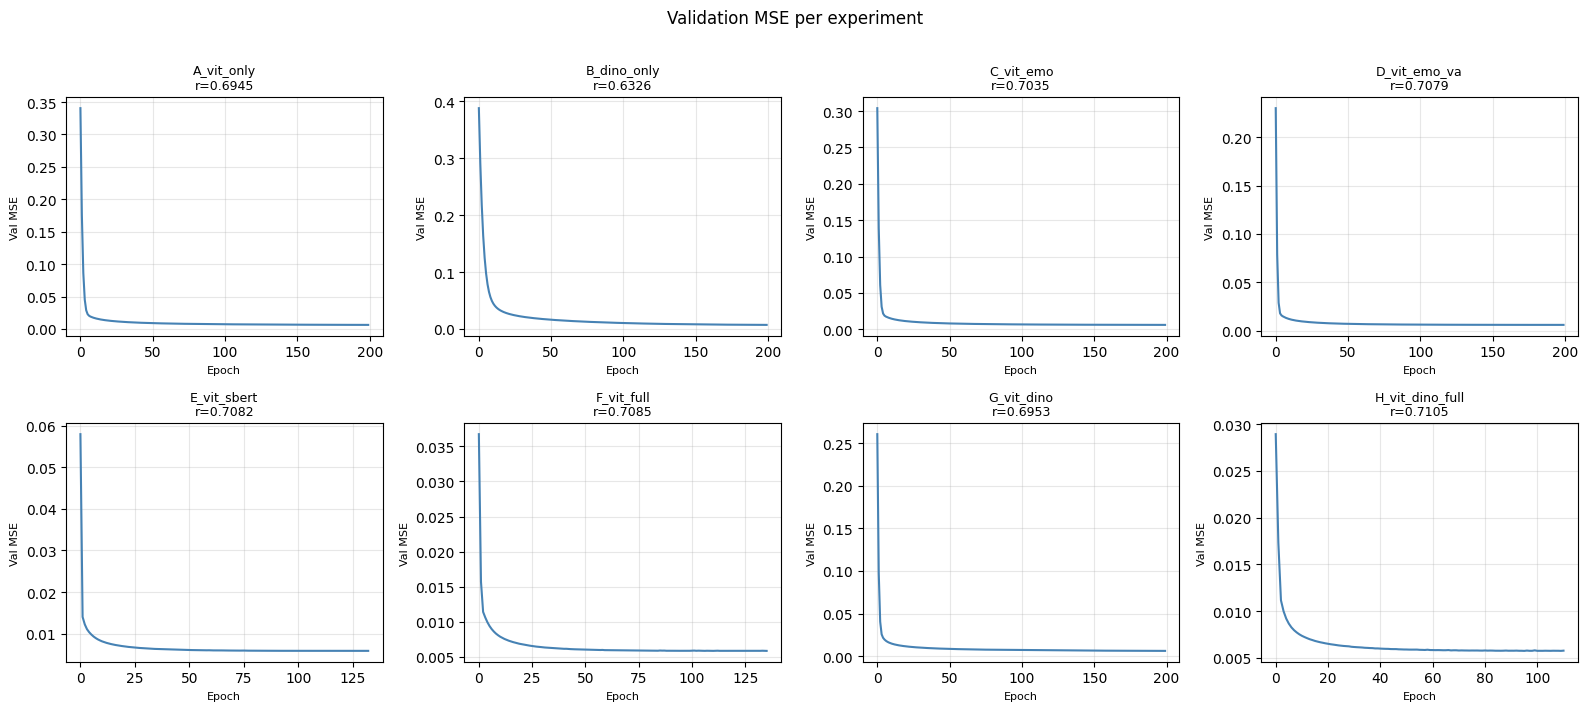

In [11]:
n     = len(EXPERIMENTS)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

for i, (name, cfg) in enumerate(EXPERIMENTS.items()):
    _, hist = trained[name]
    ax = axes[i]
    ax.plot(hist["val_mse"], color="steelblue", label="val MSE")
    ax.set_title(f"{name}\nr={hist['test_r']:.4f}", fontsize=9)
    ax.set_xlabel("Epoch", fontsize=8)
    ax.set_ylabel("Val MSE", fontsize=8)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Validation MSE per experiment", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_35473/2529249460.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)


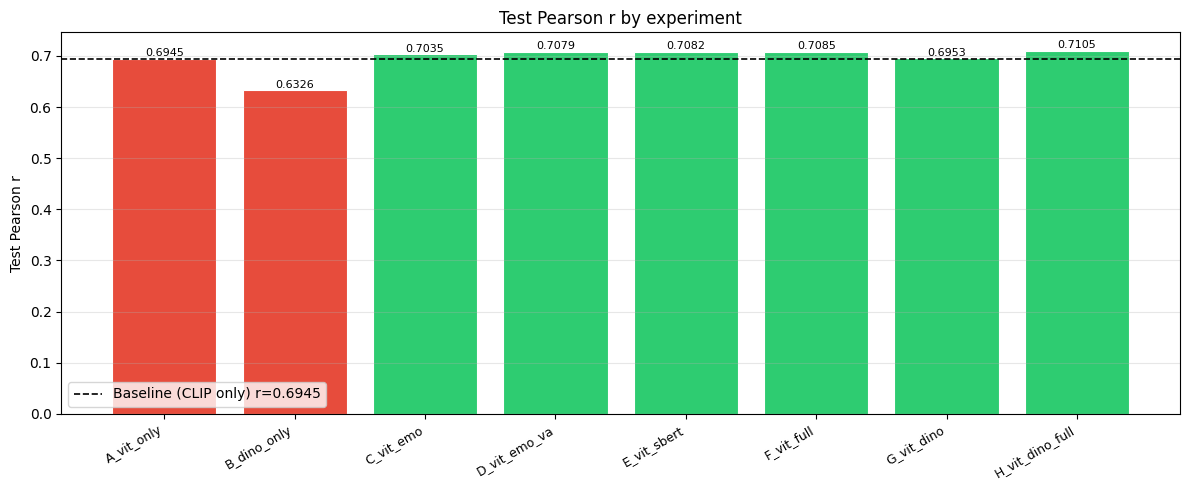

In [12]:
names  = [r["Experiment"]  for r in rows]
r_vals = [r["Test r"]      for r in rows]
colors = ["#2ecc71" if v >= baseline_r else "#e74c3c" for v in r_vals]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, r_vals, color=colors, edgecolor="white", linewidth=0.8)
ax.axhline(baseline_r, color="black", linewidth=1.2, linestyle="--", label=f"Baseline (CLIP only) r={baseline_r:.4f}")
ax.set_ylabel("Test Pearson r")
ax.set_title("Test Pearson r by experiment")
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, r_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/linear_r_comparison.png", dpi=150)
plt.show()

/tmp/ipykernel_35473/2469633484.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)


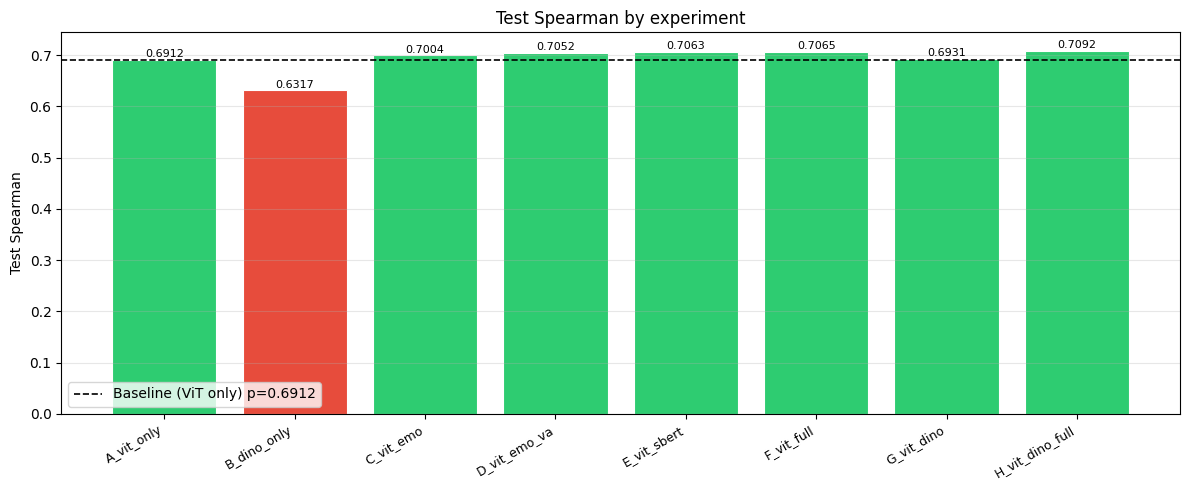

In [13]:
rho_vals = [trained[n][1]["test_rho"] for n in names]
colors_rho = ["#2ecc71" if v >= baseline_rho else "#e74c3c" for v in rho_vals]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, rho_vals, color=colors_rho, edgecolor="white", linewidth=0.8)
ax.axhline(baseline_rho, color="black", linewidth=1.2, linestyle="--",
           label=f"Baseline (ViT only) p={baseline_rho:.4f}")
ax.set_ylabel("Test Spearman")
ax.set_title("Test Spearman by experiment")
ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)
ax.legend(); ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, rho_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/linear_rho_comparison.png", dpi=150)
plt.show()

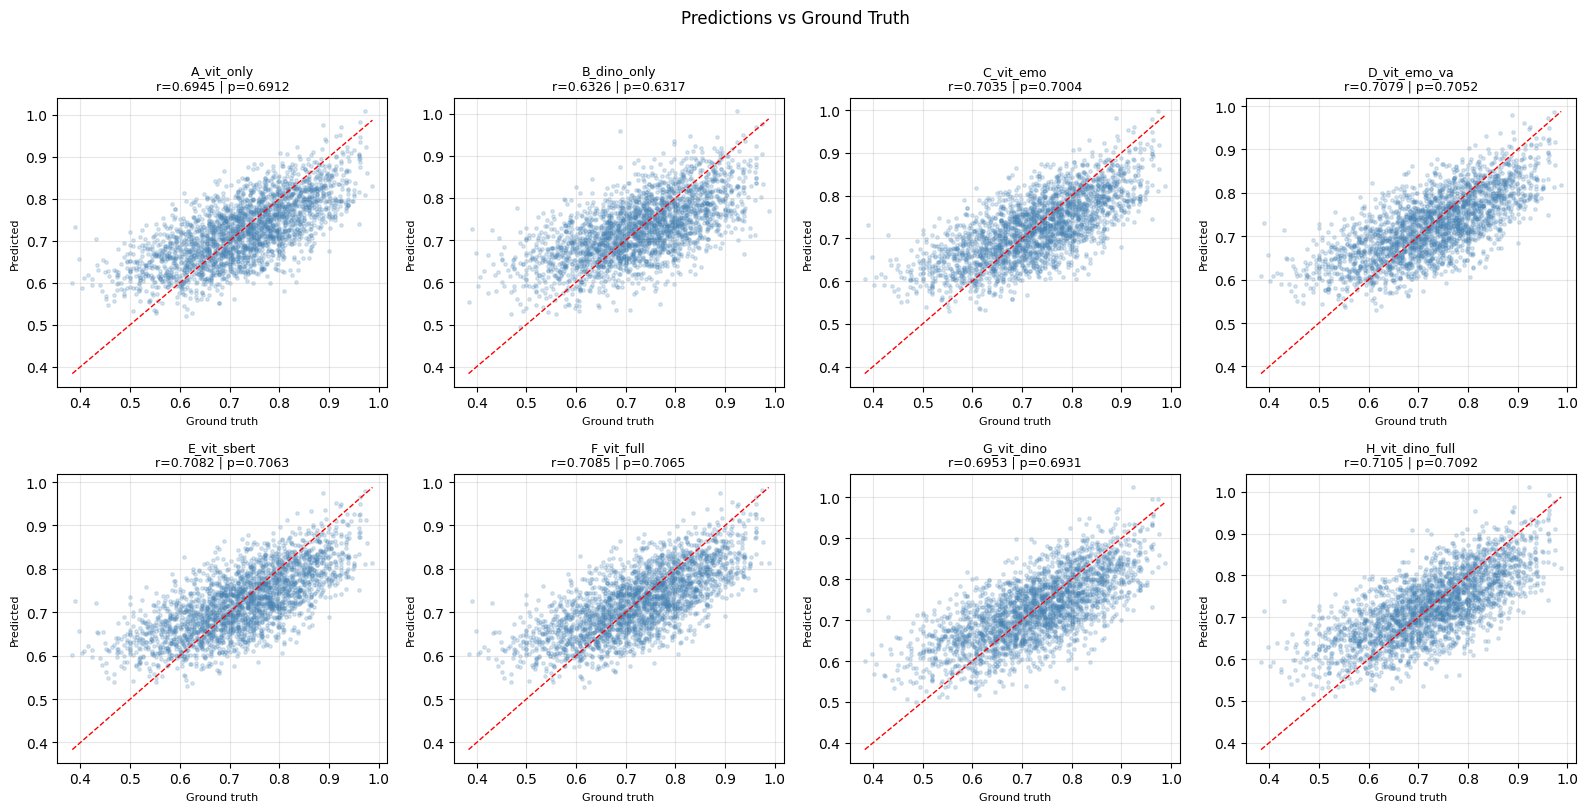

In [14]:
n = len(EXPERIMENTS)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()

for i, (name, cfg) in enumerate(EXPERIMENTS.items()):
    model, hist = trained[name]
    _, _, test_loader = make_loaders(cfg["X"])

    preds, targets = [], []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            preds.append(model(x.to(DEVICE)).cpu().numpy())
            targets.append(y.numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    ax = axes[i]
    ax.scatter(targets, preds, alpha=0.2, s=6, color="steelblue")
    lo, hi = targets.min(), targets.max()
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    ax.set_title(f"{name}\nr={hist['test_r']:.4f} | p={hist['test_rho']:.4f}", fontsize=9)
    ax.set_xlabel("Ground truth", fontsize=8)
    ax.set_ylabel("Predicted", fontsize=8)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Predictions vs Ground Truth", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/linear_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# change p

In [16]:
summary = {}
for name, (model, hist) in trained.items():
    torch.save(model.state_dict(), f"{SAVE_DIR}/linear_{name}.pt")
    summary[name] = {
        "description": EXPERIMENTS[name]["desc"],
        "input_dim" : EXPERIMENTS[name]["dim"],
        "test_mse" : hist["test_mse"],
        "test_r" : hist["test_r"],
        "delta_r_vs_clip_baseline": hist["test_r"] - baseline_r,
    }


with open(f"{SAVE_DIR}/linear_probe_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Models and summary saved to:", SAVE_DIR)
print()
print("=" * 60)
print("FINAL RANKING (Linear Probe, by Test r)")
print("=" * 60)
for name, v in sorted(summary.items(), key=lambda x: -x[1]["test_r"]):
    delta = v["delta_r_vs_clip_baseline"]
    sign  = "+" if delta >= 0 else ""
    print(f"  {name:<24} r={v['test_r']:.4f}  ({sign}{delta:.4f} vs CLIP baseline)")
print("=" * 60)

Models and summary saved to: /content/drive/MyDrive/CompNeuroscience-P1/memorability_models

FINAL RANKING (Linear Probe, by Test r)
  H_vit_dino_full          r=0.7105  (+0.0160 vs CLIP baseline)
  F_vit_full               r=0.7085  (+0.0140 vs CLIP baseline)
  E_vit_sbert              r=0.7082  (+0.0137 vs CLIP baseline)
  D_vit_emo_va             r=0.7079  (+0.0133 vs CLIP baseline)
  C_vit_emo                r=0.7035  (+0.0090 vs CLIP baseline)
  G_vit_dino               r=0.6953  (+0.0008 vs CLIP baseline)
  A_vit_only               r=0.6945  (+0.0000 vs CLIP baseline)
  B_dino_only              r=0.6326  (-0.0619 vs CLIP baseline)


In [19]:
from scipy.stats import wilcoxon
import warnings


def get_test_errors(model, X):
    _, _, test_loader = make_loaders(X)
    preds, targets = [], []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            preds.append(model(x.to(DEVICE)).cpu().numpy())
            targets.append(y.numpy())
    preds   = np.concatenate(preds)
    targets = np.concatenate(targets)
    return (preds - targets) ** 2

errors = {name: get_test_errors(trained[name][0], cfg["X"])
          for name, cfg in EXPERIMENTS.items()}

N = len(next(iter(errors.values())))


BASELINE_MAP = {
    # ViT-based
    "C_vit_emo":       "A_vit_only",
    "D_vit_emo_va":    "A_vit_only",
    "E_vit_sbert":     "A_vit_only",
    "F_vit_full":      "A_vit_only",
    # DINO-based
    "C_dino_emo":      "B_dino_only",
    "D_dino_emo_va":   "B_dino_only",
    "E_dino_sbert":    "B_dino_only",
    "F_dino_full":     "B_dino_only",
}


n_tests    = len(BASELINE_MAP)
alpha_corr = 0.05 / n_tests


rows = []
for exp_name, base_name in BASELINE_MAP.items():
    if exp_name not in errors or base_name not in errors:
        continue

    diff = errors[base_name] - errors[exp_name]   # positive = experiment better

    print(f"EXPERIMENT: {exp_name, base_name} | DIFF: {diff} | is_positive: {diff>0}")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p = wilcoxon(diff, alternative="greater", zero_method="wilcox")

    z        = (stat - N*(N+1)/4) / np.sqrt(N*(N+1)*(2*N+1)/24)
    # r_effect = abs(z) / np.sqrt(N)

    N_eff = np.sum(diff != 0)
    z = (stat - N_eff*(N_eff+1)/4) / np.sqrt(N_eff*(N_eff+1)*(2*N_eff+1)/24)
    r_effect = abs(z) / np.sqrt(N_eff)

    rows.append({
        "Experiment"    : exp_name,
        "vs. baseline"  : base_name,
        "Description"   : EXPERIMENTS[exp_name]["desc"],
        "Mean MSE"     : round(float(diff.mean()), 6),
        "W"             : round(float(stat), 1),
        "p-value"       : float(p),
        "p (fmt)"       : f"{p:.2e}" if p < 0.001 else f"{p:.4f}",
        "Effect size r" : round(r_effect, 4),
        "Sig."  : "SIGNIFICANT" if p < alpha_corr else "",
        "Direction"     : "better" if diff.mean() > 0 else "worse",
    })


print("\n\n\n\n\n\n")
wilcox_df = pd.DataFrame(rows).sort_values("p-value")

print("WILCOXON SIGNED-RANK TEST — Linear Probe")
print(f"H0: no improvement over backbone  |  Bonferroni alpha = 0.05/{n_tests} = {alpha_corr:.4f}  |  N_test = {N}")
print(wilcox_df[["Experiment","vs. baseline","Mean MSE","W","p (fmt)","Effect size r","Sig.","Direction"]].to_string(index=False))

sig = wilcox_df[wilcox_df["Sig."] == "SIGNIFICANT"]
print(f"Significant improvements (Bonferroni alpha={alpha_corr:.4f})")
if len(sig) == 0:
    print("  None reached significance after Bonferroni correction.")
else:
    for _, row in sig.iterrows():
        print(f"  {row['Experiment']:<22}  p={row['p (fmt)']:<10}  r={row['Effect size r']:.4f}")

wilcox_df.to_csv(f"{SAVE_DIR}/wilcoxon_linear.csv", index=False)


EXPERIMENT: ('C_vit_emo', 'A_vit_only') | DIFF: [-0.00047733  0.00054635  0.00053411 ...  0.00043757 -0.00039818
 -0.00029517] | is_positive: [False  True  True ...  True False False]
EXPERIMENT: ('D_vit_emo_va', 'A_vit_only') | DIFF: [-0.00078235  0.00034421  0.00067692 ...  0.00085891 -0.00091448
 -0.00035054] | is_positive: [False  True  True ...  True False False]
EXPERIMENT: ('E_vit_sbert', 'A_vit_only') | DIFF: [-0.00079351  0.00053154  0.00108583 ...  0.0004374  -0.00095212
 -0.00086188] | is_positive: [False  True  True ...  True False False]
EXPERIMENT: ('F_vit_full', 'A_vit_only') | DIFF: [-0.00078206  0.00070868  0.00120074 ...  0.00062665 -0.00101381
 -0.00064193] | is_positive: [False  True  True ...  True False False]







WILCOXON SIGNED-RANK TEST — Linear Probe
H0: no improvement over backbone  |  Bonferroni alpha = 0.05/8 = 0.0063  |  N_test = 2523
  Experiment vs. baseline  Mean MSE         W  p (fmt)  Effect size r        Sig. Direction
   C_vit_emo   A_vit_only  0

In [20]:
df = wilcox_df.copy()

df = df.sort_values("p-value")

styled = (
    df[["Experiment","vs. baseline","Mean MSE","p-value","Effect size r","Sig."]]
    .style
    .format({
        "Mean MSE": "{:.6f}",
        "p-value": "{:.2e}",
        "Effect size r": "{:.3f}"
    })

    .background_gradient(subset=["Effect size r"], cmap="Blues")
    .applymap(lambda v: "color: green; font-weight: bold" if v == "SIGNIFICANT" else "",
              subset=["Sig."])
    .set_caption("Wilcoxon Signed-Rank Test Results (Linear Probe)")
)

styled

/tmp/ipykernel_35473/604297902.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: "color: green; font-weight: bold" if v == "SIGNIFICANT" else "",


,Experiment,vs. baseline,Mean MSE,p-value,Effect size r,Sig.
0,C_vit_emo,A_vit_only,0.000148,2.54e-14,0.150,SIGNIFICANT
1,D_vit_emo_va,A_vit_only,0.000219,5.81e-11,0.128,SIGNIFICANT
2,E_vit_sbert,A_vit_only,0.000223,6.98e-10,0.121,SIGNIFICANT
3,F_vit_full,A_vit_only,0.000231,9.91e-10,0.119,SIGNIFICANT


### Evaluating Emotion Classifications

In [21]:
df = pd.read_parquet(f"{FEATURES_DIR}/lamem_features_full.parquet")
emo_df = df[df.original_emotion != ''].copy()
emo_df['original_emotion'] = emo_df['original_emotion'].replace('sad', 'sadness')
print("Unique values in original_emotion after replacement:", emo_df['original_emotion'].unique())

Unique values in original_emotion after replacement: ['amusement' 'excitement' 'awe' 'contentment' 'sadness']


In [22]:
emo_df.original_emotion.unique(), emo_df.dominant_emotion.unique()

(array(['amusement', 'excitement', 'awe', 'contentment', 'sadness'],
       dtype=object),
 array(['amusement', 'excitement', 'sadness', 'awe', 'contentment'],
       dtype=object))

Images with ground truth emotion: 540
Accuracy: 0.4870

              precision    recall  f1-score   support

   amusement       0.73      0.38      0.50       100
         awe       0.45      0.29      0.36       102
 contentment       0.30      0.54      0.38        67
  excitement       0.49      0.22      0.30       105
     sadness       0.54      0.82      0.65       166

    accuracy                           0.49       540
   macro avg       0.50      0.45      0.44       540
weighted avg       0.52      0.49      0.47       540



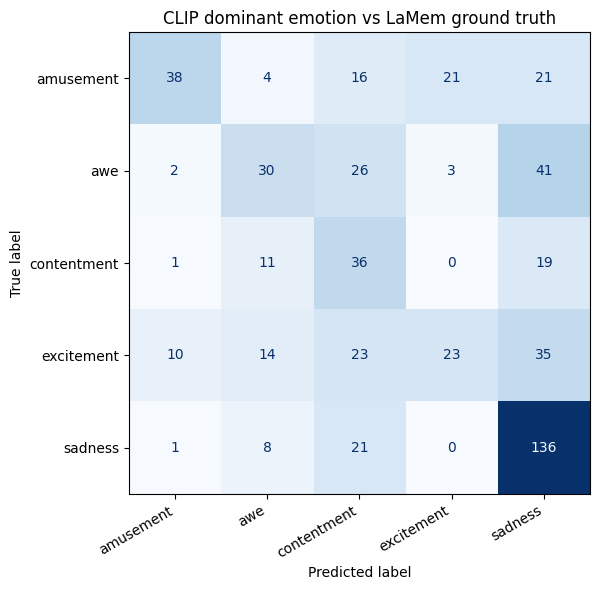

/tmp/ipykernel_35473/3373621213.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right")
/tmp/ipykernel_35473/3373621213.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right")


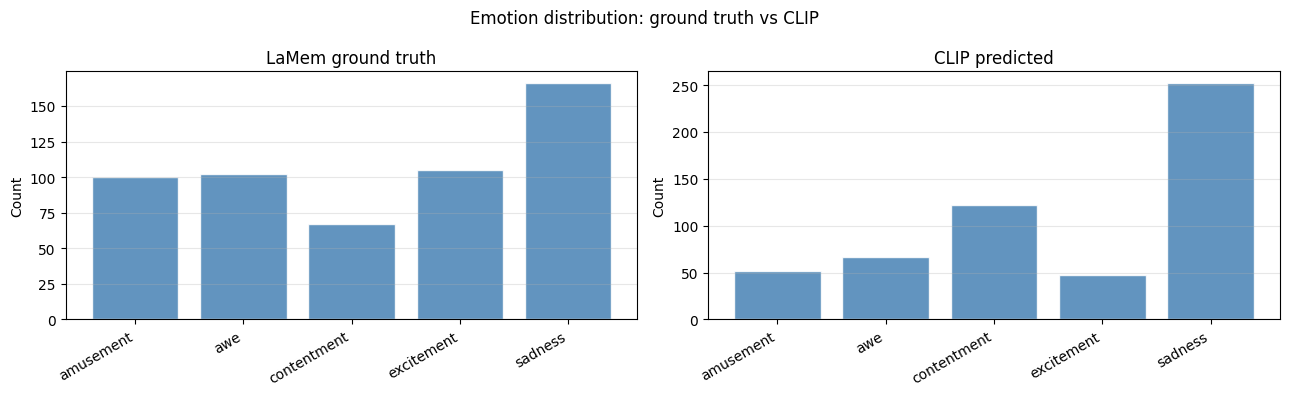

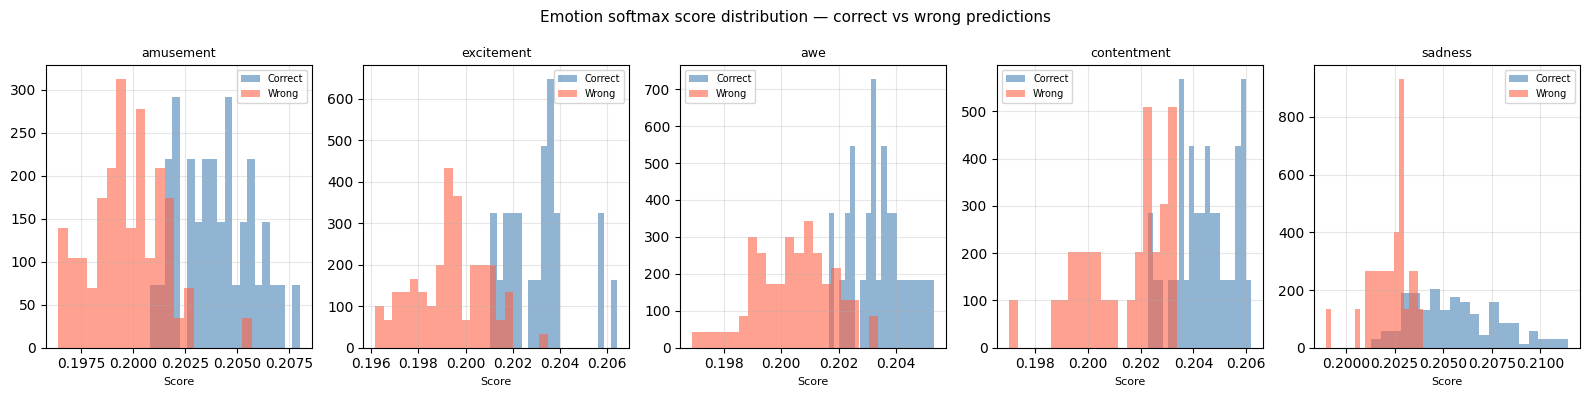

Memscore by prediction correctness:
         count    mean     std     min     25%     50%     75%     max
correct                                                               
False    277.0  0.7345  0.1218  0.3951  0.6463  0.7590  0.8250  0.9740
True     263.0  0.7478  0.1341  0.3671  0.6581  0.7867  0.8537  0.9512


/tmp/ipykernel_35473/3373621213.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(emotions_sorted, rotation=30, ha="right")


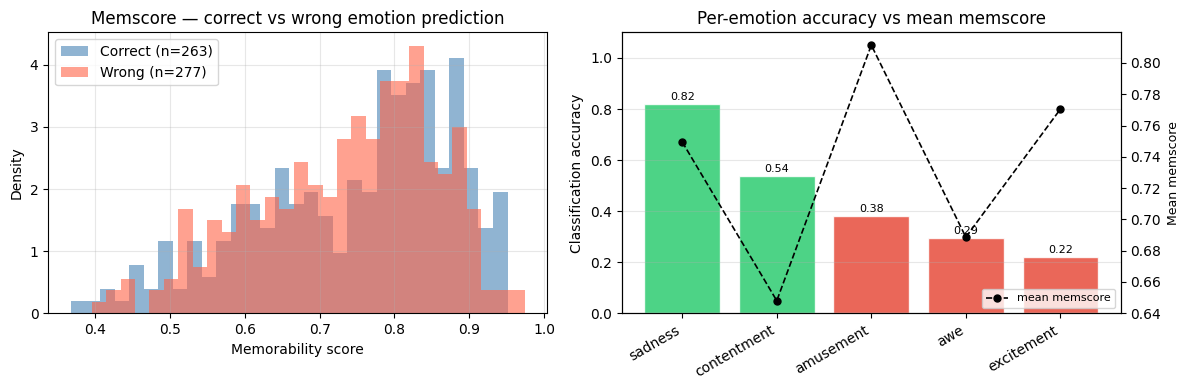

Top confusions (predicted | true | count):
  amusement      most confused with sadness        (n=21)
  awe            most confused with sadness        (n=41)
  contentment    most confused with sadness        (n=19)
  excitement     most confused with sadness        (n=35)
  sadness        most confused with contentment    (n=21)
Top-1 accuracy (dominant_emotion):            0.4870
Top-2 accuracy (dominant or secondary):       0.7000


In [23]:
y_true = emo_df["original_emotion"].str.lower().str.strip()
y_pred = emo_df["dominant_emotion"].str.lower().str.strip()

common_labels = sorted(set(y_true.unique()) & set(EMOTIONS))

print(f"Images with ground truth emotion: {len(emo_df)}")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, labels=common_labels))


fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_true, y_pred, labels=common_labels)
ConfusionMatrixDisplay(cm, display_labels=common_labels).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("CLIP dominant emotion vs LaMem ground truth")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/emotion_confusion_matrix.png", dpi=150)
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (col, title) in zip(axes, [
    ("original_emotion", "LaMem ground truth"),
    ("dominant_emotion", "CLIP predicted"),
]):
    counts = emo_df[col].str.lower().str.strip().value_counts().reindex(common_labels, fill_value=0)
    ax.bar(counts.index, counts.values, color="steelblue", alpha=0.85, edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.set_xticklabels(counts.index, rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Emotion distribution: ground truth vs CLIP", fontsize=12)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/emotion_distribution.png", dpi=150)
plt.show()


score_cols = [f"emotion_{e}" for e in EMOTIONS]
fig, axes = plt.subplots(1, len(EMOTIONS), figsize=(16, 4), sharey=False)
for ax, e in zip(axes, EMOTIONS):
    col = f"emotion_{e}"
    for match, label, color in [(True, "Correct", "steelblue"), (False, "Wrong", "tomato")]:
        subset = emo_df[emo_df["original_emotion"].str.lower().str.strip() == e]
        matched = subset[subset["dominant_emotion"].str.lower().str.strip() == e]
        missed  = subset[subset["dominant_emotion"].str.lower().str.strip() != e]
        group   = matched if match else missed
        if len(group):
            ax.hist(group[col], bins=20, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(e, fontsize=9)
    ax.set_xlabel("Score", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
plt.suptitle("Emotion softmax score distribution — correct vs wrong predictions", fontsize=11)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/emotion_score_distributions.png", dpi=150)
plt.show()


emo_df["correct"] = (y_true == y_pred)
emo_df["error_abs"] = (emo_df["memscore"] - emo_df["memscore"].mean()).abs()

print("Memscore by prediction correctness:")
print(emo_df.groupby("correct")["memscore"].describe().round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for correct, label, color in [(True, "Correct", "steelblue"), (False, "Wrong", "tomato")]:
    subset = emo_df[emo_df["correct"] == correct]
    axes[0].hist(subset["memscore"], bins=30, alpha=0.6, label=f"{label} (n={len(subset)})",
                 color=color, density=True)
axes[0].set_xlabel("Memorability score")
axes[0].set_ylabel("Density")
axes[0].set_title("Memscore — correct vs wrong emotion prediction")
axes[0].legend()
axes[0].grid(alpha=0.3)

per_emotion = []
for e in common_labels:
    subset = emo_df[emo_df["original_emotion"].str.lower().str.strip() == e]
    acc    = (subset["dominant_emotion"].str.lower().str.strip() == e).mean()
    per_emotion.append((e, acc, subset["memscore"].mean()))

emotions_sorted, accs, mean_mem = zip(*sorted(per_emotion, key=lambda x: -x[1]))
colors = ["#2ecc71" if a >= 0.5 else "#e74c3c" for a in accs]
bars = axes[1].bar(emotions_sorted, accs, color=colors, edgecolor="white", alpha=0.85)
ax2 = axes[1].twinx()
ax2.plot(emotions_sorted, mean_mem, "o--", color="black", linewidth=1.2, markersize=5, label="mean memscore")
ax2.set_ylabel("Mean memscore", fontsize=9)
ax2.legend(loc="lower right", fontsize=8)
for bar, val in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=8)
axes[1].set_ylabel("Classification accuracy")
axes[1].set_title("Per-emotion accuracy vs mean memscore")
axes[1].set_xticklabels(emotions_sorted, rotation=30, ha="right")
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/emotion_memscore_analysis.png", dpi=150)
plt.show()


conf_matrix_df = pd.DataFrame(cm, index=common_labels, columns=common_labels)
print("Top confusions (predicted | true | count):")
for true_e in common_labels:
    row = conf_matrix_df.loc[true_e].drop(true_e).sort_values(ascending=False)
    top = row.iloc[0]
    print(f"  {true_e:<14} most confused with {row.index[0]:<14} (n={int(top)})")


secondary_match = (
    emo_df["original_emotion"].str.lower().str.strip() ==
    emo_df["secondary_emotion"].str.lower().str.strip()
)
top1_match = emo_df["correct"]
top2_match = top1_match | secondary_match

print(f"Top-1 accuracy (dominant_emotion):            {top1_match.mean():.4f}")
print(f"Top-2 accuracy (dominant or secondary):       {top2_match.mean():.4f}")

### Visualizing Results

In [25]:
import clip as openai_clip
import torch.nn.functional as F
from PIL import Image

In [49]:
clip_vis, clip_preprocess_vis = openai_clip.load("ViT-L/14", device=DEVICE)
clip_vis = clip_vis.float().to(DEVICE)
clip_vis.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)


In [50]:
emotion_prompt_tokens = openai_clip.tokenize(
    [f"a photo that conveys {e}" for e in EMOTIONS]
).to(DEVICE)

with torch.no_grad():
    emotion_text_feats = clip_vis.encode_text(emotion_prompt_tokens).float()
    emotion_text_feats = emotion_text_feats / (emotion_text_feats.norm(dim=-1, keepdim=True) + 1e-8)

In [81]:
# ============================================================
# ATTENTION ROLLOUT — alternativa ao Grad-CAM para CLIP ViT
# ============================================================

def get_attention_rollout(image_path, head_fusion="mean", discard_ratio=0.9):
    """
    Attention Rollout (Abnar & Zuidema 2020) para CLIP ViT-L/14.

    Multiplica os mapas de atencao de todas as camadas para propagar
    a importancia do CLS token ate os patches de entrada.

    Args:
        image_path   : caminho para a imagem
        head_fusion  : como agregar as heads — "mean", "max" ou "min"
        discard_ratio: fracao dos patches de menor atencao a zerar (ruido)

    Returns:
        (img PIL 224x224, cam np.array 224x224 normalizado [0,1])
    """
    img = Image.open(image_path).convert("RGB")
    x   = clip_preprocess_vis(img).unsqueeze(0).to(DEVICE).float()

    attention_maps = []

    def make_attn_hook(block):
        """Registra hook no modulo de atencao de cada resblock."""
        def hook(m, inp, out):
            # inp[0]: query [257, 1, 1024]
            # Recomputa os pesos de atencao manualmente pois o CLIP
            # nao os expoe diretamente na saida do modulo attn
            q, k = inp[0], inp[1]
            B    = q.shape[1]
            num_heads   = m.num_heads
            head_dim    = q.shape[-1] // num_heads
            scale       = head_dim ** -0.5

            # Projeta q e k com os pesos do modulo
            q_proj = torch.nn.functional.linear(q, m.in_proj_weight[:m.embed_dim],
                                                  m.in_proj_bias[:m.embed_dim])
            k_proj = torch.nn.functional.linear(k, m.in_proj_weight[m.embed_dim:2*m.embed_dim],
                                                  m.in_proj_bias[m.embed_dim:2*m.embed_dim])

            # Reshape para multi-head: [num_heads, seq_len, head_dim]
            seq_len = q.shape[0]
            q_proj  = q_proj.reshape(seq_len, B * num_heads, head_dim).transpose(0, 1)
            k_proj  = k_proj.reshape(seq_len, B * num_heads, head_dim).transpose(0, 1)

            # Attn weights: [B*num_heads, seq_len, seq_len]
            attn = torch.bmm(q_proj, k_proj.transpose(-2, -1)) * scale
            attn = torch.softmax(attn, dim=-1)

            # Reshape para [B, num_heads, seq_len, seq_len]
            attn = attn.reshape(B, num_heads, seq_len, seq_len)

            attention_maps.append(attn.detach().cpu())

        return hook

    handles = []
    for block in clip_vis.visual.transformer.resblocks:
        handles.append(block.attn.register_forward_hook(make_attn_hook(block)))

    with torch.no_grad():
        clip_vis.encode_image(x)

    for h in handles:
        h.remove()

    # Attention Rollout
    # Comeca com matriz identidade [257, 257]
    seq_len = attention_maps[0].shape[-1]
    result  = torch.eye(seq_len)

    for attn in attention_maps:
        # attn: [1, num_heads, 257, 257]
        attn = attn.squeeze(0)   # [num_heads, 257, 257]

        if head_fusion == "mean":
            attn_fused = attn.mean(dim=0)   # [257, 257]
        elif head_fusion == "max":
            attn_fused = attn.max(dim=0).values
        elif head_fusion == "min":
            attn_fused = attn.min(dim=0).values

        # Adiciona identidade (residual connection) e normaliza
        attn_fused = attn_fused + torch.eye(seq_len)
        attn_fused = attn_fused / attn_fused.sum(dim=-1, keepdim=True)

        result = torch.matmul(attn_fused, result)

    # Pega a linha do CLS token (indice 0) sobre os patches (indices 1:)
    mask = result[0, 1:]   # [256]

    # Descarta patches de baixa atencao (ruido)
    if discard_ratio > 0:
        threshold = mask.quantile(discard_ratio)
        mask = torch.where(mask >= threshold, mask, torch.zeros_like(mask))

    # Normaliza para [0, 1]
    mask = mask - mask.min()
    mask = mask / (mask.max() + 1e-8)

    # Reshape para grade espacial e interpola para 224x224
    side = int(mask.shape[0] ** 0.5)   # 16
    cam  = mask.reshape(side, side)

    cam = torch.nn.functional.interpolate(
        cam.unsqueeze(0).unsqueeze(0).float(),
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    ).squeeze()

    return img.resize((224, 224)), cam.numpy()


# ── Wrappers com mesma interface de antes ────────────────────
# (emotion_idx e linear_model sao ignorados — rollout e puramente visual)

def get_clip_gradcam_emotion(image_path, emotion_idx, discard_ratio=0.9):
    return get_attention_rollout(image_path, head_fusion="mean",
                                 discard_ratio=discard_ratio)

def get_clip_gradcam_memscore(image_path, linear_model, extra_feats=None,
                               discard_ratio=0.9):
    return get_attention_rollout(image_path, head_fusion="mean",
                                 discard_ratio=discard_ratio)


# ── Mapa de features extras por experimento ──────────────────

EXTRA_FEATS_FN = {
    "A_vit_only"      : lambda i: None,
    "B_dino_only"     : lambda i: None,
    "C_vit_emo"       : lambda i: emo_norm[i],
    "D_vit_emo_va"    : lambda i: np.concatenate([emo_norm[i], va_norm[i]]),
    "E_vit_sbert"     : lambda i: sbert_norm[i],
    "F_vit_full"      : lambda i: np.concatenate([emo_norm[i], va_norm[i], sbert_norm[i]]),
    "G_vit_dino"      : lambda i: dino_norm[i],
    "H_vit_dino_full" : lambda i: np.concatenate([dino_norm[i], emo_norm[i], va_norm[i], sbert_norm[i]]),
}


# ============================================================
# EDGE CASES
# ============================================================

def get_edge_cases(exp_name, model):
    X = EXPERIMENTS[exp_name]["X"]
    _, _, test_loader = make_loaders(X)
    preds, targets = [], []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            preds.append(model(x.to(DEVICE)).cpu().numpy())
            targets.append(y.numpy())
    preds   = np.concatenate(preds)
    targets = np.concatenate(targets)
    errors  = np.abs(preds - targets)
    best_i  = int(np.argmin(errors))
    worst_i = int(np.argmax(errors))
    return (
        (test_idx[best_i],  preds[best_i],  targets[best_i]),
        (test_idx[worst_i], preds[worst_i], targets[worst_i]),
    )


# ============================================================
# VISUALIZACAO
# ============================================================

def plot_gradcam_for_experiment(exp_name):
    model = trained[exp_name][0]
    hist  = trained[exp_name][1]

    (best_idx, best_pred, best_true), (worst_idx, worst_pred, worst_true) = get_edge_cases(exp_name, model)

    fig, axes = plt.subplots(2, 3, figsize=(14, 10))

    for row, (g_idx, pred, true, label) in enumerate([
        (best_idx,  best_pred,  best_true,  "Best"),
        (worst_idx, worst_pred, worst_true, "Worst"),
    ]):
        img_path = f"{ROOT_DIR}/lamem_images/{df.iloc[g_idx]['name']}"
        dom_emo  = str(df.iloc[g_idx]["dominant_emotion"]).lower().strip()
        extra    = EXTRA_FEATS_FN[exp_name](g_idx)

        img_orig, cam = get_attention_rollout(img_path, head_fusion="mean", discard_ratio=0.9)

        # Coluna 0 — imagem original
        axes[row][0].imshow(img_orig)
        axes[row][0].set_title(
            f"{label} case\n"
            f"true={true:.3f}  pred={pred:.3f}  err={abs(pred-true):.3f}\n"
            f"emotion: {dom_emo}  |  valence={df.iloc[g_idx]['valence']:.2f}",
            fontsize=8
        )
        axes[row][0].axis("off")

        # Coluna 1 — Attention Rollout overlay
        axes[row][1].imshow(img_orig)
        axes[row][1].imshow(cam, cmap="jet", alpha=0.55, vmin=0, vmax=1)
        axes[row][1].set_title("Attention Rollout\n(onde o CLS presta atencao)", fontsize=8)
        axes[row][1].axis("off")

        # Coluna 2 — Heatmap puro
        im = axes[row][2].imshow(cam, cmap="jet", vmin=0, vmax=1)
        axes[row][2].set_title("Attention map\n(16x16 patches → 224x224)", fontsize=8)
        axes[row][2].axis("off")
        plt.colorbar(im, ax=axes[row][2], fraction=0.046, pad=0.04)

    plt.suptitle(
        f"{exp_name} — {EXPERIMENTS[exp_name]['desc']}\n"
        f"test r={hist['test_r']:.4f}  ρ={hist['test_rho']:.4f}",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/attn_rollout_{exp_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Salvo em {SAVE_DIR}/attn_rollout_{exp_name}.png")


# ============================================================
# RODA
# ============================================================

VIT_EXPERIMENTS = [
    "A_vit_only",
    "C_vit_emo",
    "D_vit_emo_va",
    "E_vit_sbert",
    "F_vit_full",
]

for exp_name in VIT_EXPERIMENTS:
    print(f"\n>>> {exp_name}")
    plot_gradcam_for_experiment(exp_name)

Output hidden; open in https://colab.research.google.com to view.

In [82]:
# ============================================================
# TOP-K EDGE CASES
# ============================================================

def get_top_k_edge_cases(exp_name, model, k=5):
    """Retorna os k melhores e k piores casos do test set."""
    X = EXPERIMENTS[exp_name]["X"]
    _, _, test_loader = make_loaders(X)
    preds, targets = [], []
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            preds.append(model(x.to(DEVICE)).cpu().numpy())
            targets.append(y.numpy())
    preds   = np.concatenate(preds)
    targets = np.concatenate(targets)
    errors  = np.abs(preds - targets)

    best_i  = np.argsort(errors)[:k]    # k menores erros
    worst_i = np.argsort(errors)[-k:][::-1]  # k maiores erros

    best_cases  = [(test_idx[i], preds[i], targets[i], errors[i]) for i in best_i]
    worst_cases = [(test_idx[i], preds[i], targets[i], errors[i]) for i in worst_i]
    return best_cases, worst_cases


# ============================================================
# VISUALIZACAO TOP-K
# ============================================================

def plot_topk_attention(exp_name, k=5, discard_ratio=0.9):
    """
    Plota um grid com os top-k melhores e piores casos.
    Cada linha e uma imagem, cada coluna e: original | rollout overlay | heatmap puro.
    """
    model = trained[exp_name][0]
    hist  = trained[exp_name][1]

    best_cases, worst_cases = get_top_k_edge_cases(exp_name, model, k=k)

    for group_label, cases in [("BEST", best_cases), ("WORST", worst_cases)]:

        fig, axes = plt.subplots(k, 3, figsize=(13, k * 4))
        if k == 1:
            axes = axes[np.newaxis, :]

        for row, (g_idx, pred, true, err) in enumerate(cases):
            img_path = f"{ROOT_DIR}/lamem_images/{df.iloc[g_idx]['name']}"
            dom_emo  = str(df.iloc[g_idx]["dominant_emotion"]).lower().strip()

            img_orig, cam = get_attention_rollout(
                img_path,
                head_fusion="mean",
                discard_ratio=discard_ratio,
            )

            # Coluna 0 — original
            axes[row][0].imshow(img_orig)
            axes[row][0].set_title(
                f"true={true:.3f}  pred={pred:.3f}  err={err:.3f}\n"
                f"emotion: {dom_emo}  |  valence={df.iloc[g_idx]['valence']:.2f}",
                fontsize=8
            )
            axes[row][0].axis("off")

            # Coluna 1 — overlay
            axes[row][1].imshow(img_orig)
            axes[row][1].imshow(cam, cmap="jet", alpha=0.5, vmin=0, vmax=1)
            axes[row][1].set_title("Attention overlay", fontsize=8)
            axes[row][1].axis("off")

            # Coluna 2 — heatmap puro com colorbar
            im = axes[row][2].imshow(cam, cmap="jet", vmin=0, vmax=1)
            axes[row][2].set_title("Attention map", fontsize=8)
            axes[row][2].axis("off")
            plt.colorbar(im, ax=axes[row][2], fraction=0.046, pad=0.04)

        fig.suptitle(
            f"{group_label} {k} — {exp_name}\n"
            f"{EXPERIMENTS[exp_name]['desc']}\n"
            f"test r={hist['test_r']:.4f}  ρ={hist['test_rho']:.4f}",
            fontsize=11, y=1.01
        )
        plt.tight_layout()

        fname = f"{SAVE_DIR}/topk_{group_label.lower()}_{exp_name}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Salvo em {fname}")


# ============================================================
# RODA
# ============================================================

VIT_EXPERIMENTS = [
    "A_vit_only",
    "C_vit_emo",
    "D_vit_emo_va",
    "E_vit_sbert",
    "F_vit_full",
]

for exp_name in VIT_EXPERIMENTS:
    print(f"\n>>> {exp_name}")
    plot_topk_attention(exp_name, k=5, discard_ratio=0.9)

Output hidden; open in https://colab.research.google.com to view.